# BÀI TẬP VỀ NHÀ TUẦN 03 (PROBLEM SET 03)
## Môn học: Xác suất Thống kê (UET.MAT1052)
### Chủ đề: Ngữ Pháp Đồ Họa, Thao Tác Dữ Liệu & Nghịch Lý Simpson (Grammar of Graphics, Data Wrangling & Simpson's Paradox)

---
**Họ và tên sinh viên:** Nguyễn Minh Đức 
**Mã số sinh viên (MSV):** 25021352
**Lớp học phần:** UET.MAT1052_51  

> **Hướng dẫn:** Chạy tuần tự các ô code bằng tổ hợp phím `Shift + Enter`. Hoàn thành các phần `# TODO:` và trả lời câu hỏi vào các ô Markdown tương ứng.

In [1]:
import numpy as np
import pandas as pd
import os
from plotnine import (
    ggplot,
    aes,
    geom_point,
    geom_line,
    labs,
    theme_minimal
)

# Định vị đường dẫn dữ liệu
data_dir = "du-lieu" if os.path.exists("du-lieu") else "../03-thuc-hanh-python/du-lieu"
print(f"Thư mục dữ liệu đang sử dụng: {data_dir}")

Thư mục dữ liệu đang sử dụng: ../03-thuc-hanh-python/du-lieu


### BÀI 1: NGỮ PHÁP ĐỒ HỌA & PHÂN TÍCH CHUỖI DỮ LIỆU SỐ CA SINH (US BIRTHS) (2.5 ĐIỂM)

Tập dữ liệu `us_births.csv` ghi nhận số lượng ca sinh hàng ngày tại Hoa Kỳ trong giai đoạn 1969 – 1988.
Ta sẽ đọc dữ liệu và khám phá hiện tượng chu kỳ tuần cũng như các ngày lễ đặc biệt.

In [6]:
# 1. Đọc dữ liệu số ca sinh
df_births = pd.read_csv(r"D:\xacsuatthongke\Tuan 3\us_births.csv")
print("5 dòng đầu tiên của tập dữ liệu:")
display(df_births.head())
print(f"Tổng số dòng: {len(df_births)} quan sát.")

5 dòng đầu tiên của tập dữ liệu:


,year,month,date_of_month,day_of_week,day_of_year,births
0,1978,1,1,7,1,4535
1,1978,1,2,1,2,9285
2,1978,1,3,2,3,9526
3,1978,1,4,3,4,9484
4,1978,1,5,4,5,9268


Tổng số dòng: 4018 quan sát.


Index(['year', 'month', 'date_of_month', 'day_of_week', 'day_of_year',
       'births'],
      dtype='str')
<ggplot: (640 x 480)>


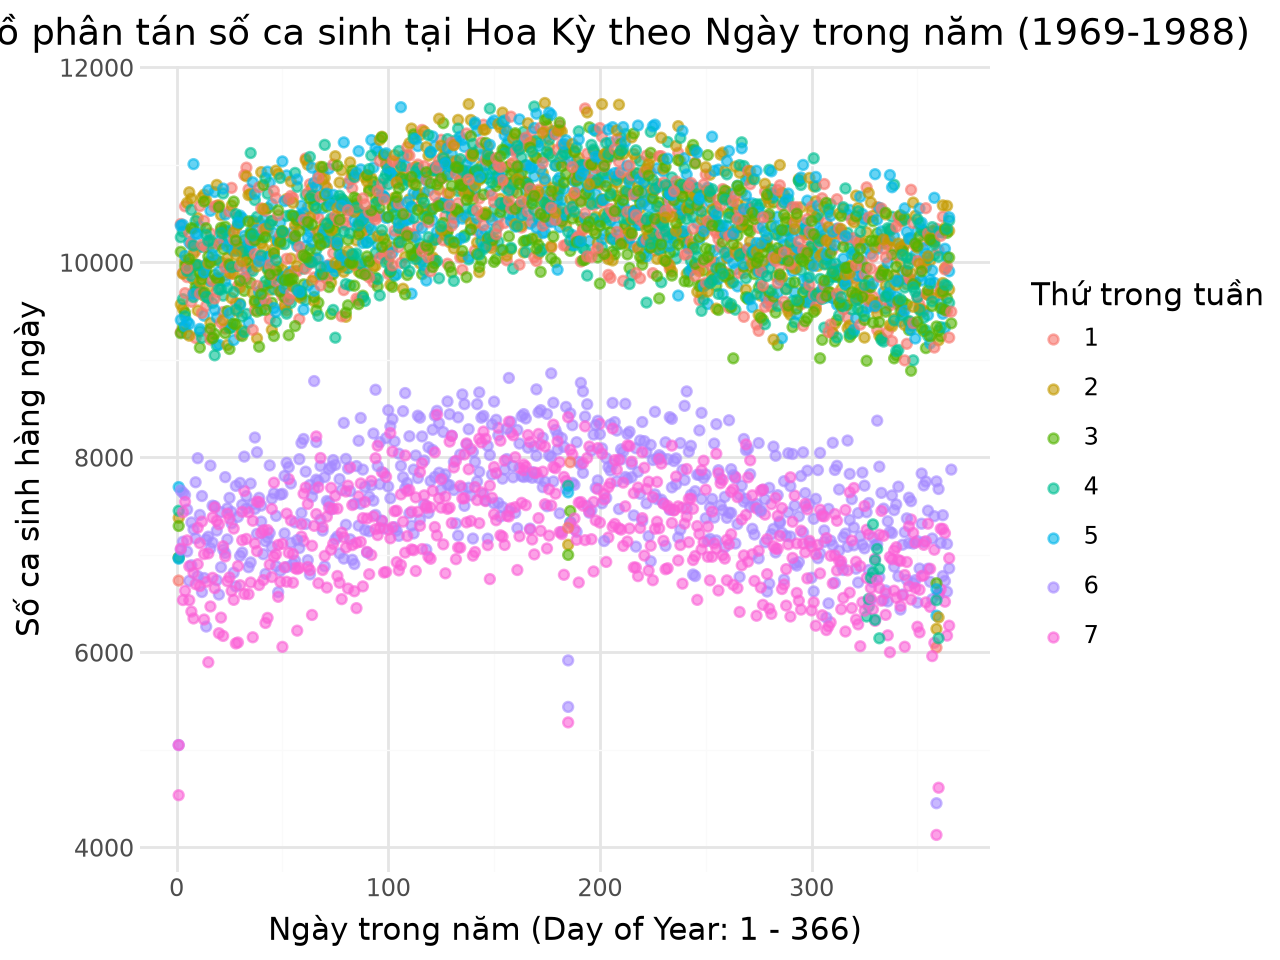

In [13]:
# 2. Trực quan hóa số ca sinh theo ngày trong năm (day_of_year)
# Ánh xạ ngày trong tuần (day_of_week) vào kênh màu sắc (color)
print(df_births.columns)

p_births = (
    ggplot(df_births, aes(x="day_of_year", y="births", color="factor(day_of_week)"))
    + geom_point(alpha=0.6, size=1.5)
    + labs(
        title="Biểu đồ phân tán số ca sinh tại Hoa Kỳ theo Ngày trong năm (1969-1988)",
        x="Ngày trong năm (Day of Year: 1 - 366)",
        y="Số ca sinh hàng ngày",
        color="Thứ trong tuần",
    )
    + theme_minimal()
)
print(p_births)
p_births.show()



In [22]:
from plotnine import scale_color_manual


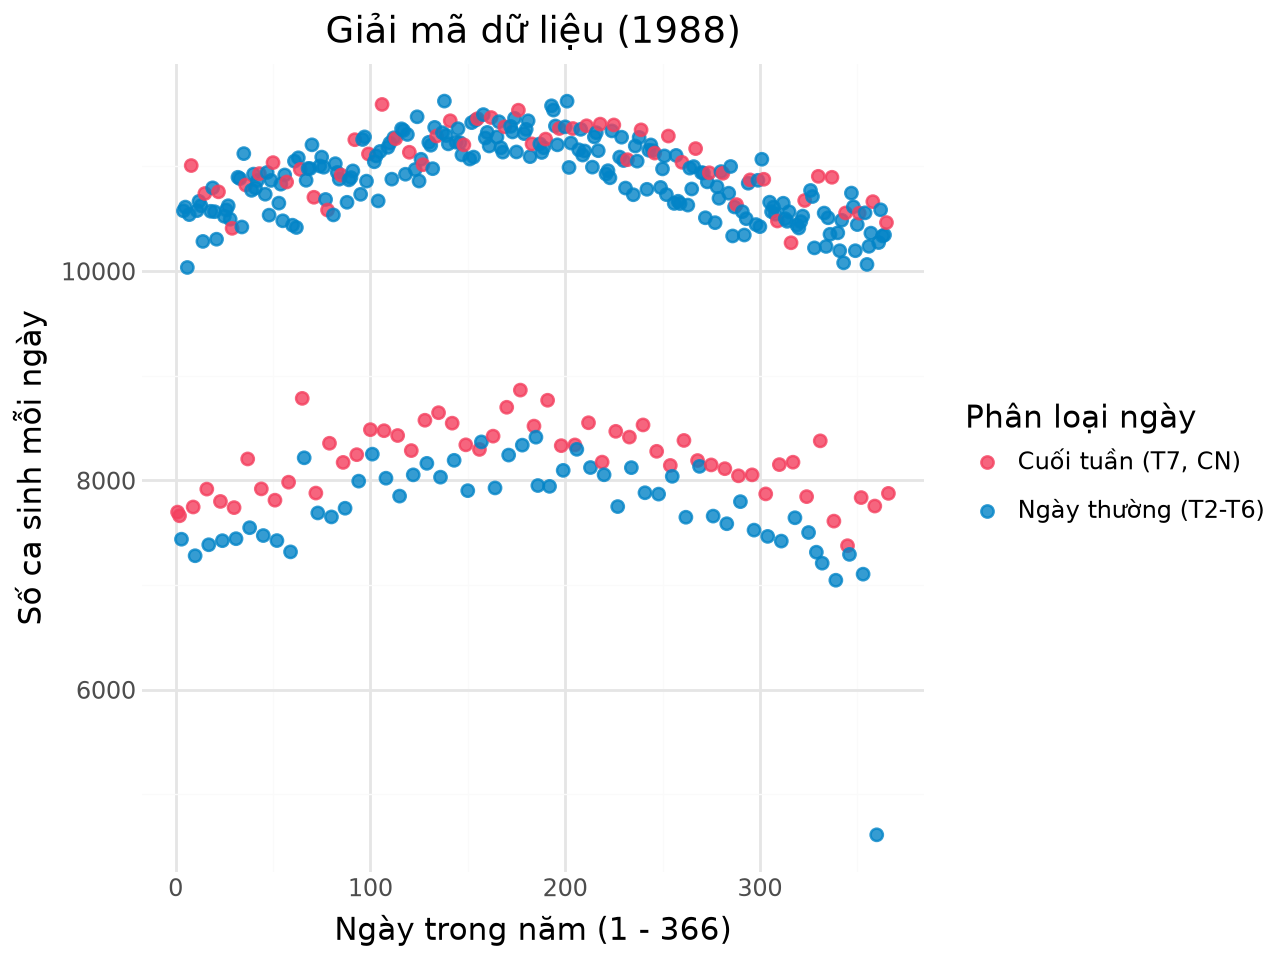

In [23]:
births_1988 = df_births.query("year == 1988").copy()

# 1. Sửa lại điều kiện: Thứ 7 là 5, Chủ Nhật là 6
births_1988["nhom_ngay"] = births_1988["day_of_week"].apply(
    lambda x: "Cuối tuần (T7, CN)" if x in [5, 6] else "Ngày thường (T2-T6)"
)

p_bands = (
    ggplot(
        births_1988,
        aes(
            x="day_of_year",
            y="births",
            color="nhom_ngay"  # 2. ĐÃ XÓA SỐ 2 THỪA Ở ĐÂY
        )
    )
    + geom_point(size=2, alpha=0.8)
    + scale_color_manual(
        values={
            "Ngày thường (T2-T6)": "#0284c7",
            "Cuối tuần (T7, CN)": "#f43f5e",
        }
    )
    + labs(
        title="Giải mã dữ liệu (1988)",
        x="Ngày trong năm (1 - 366)",
        y="Số ca sinh mỗi ngày",
        color="Phân loại ngày",
    )
    + theme_minimal()
)

# Hiển thị biểu đồ
p_bands.show()


**Trả lời câu hỏi Bài 1:**

1. *So sánh Scatter plot và Line plot:*
> *Scatter plot (Biểu đồ phân tán): Trực quan hóa từng điểm dữ liệu riêng lẻ độc lập (mỗi ngày là một chấm). Giúp dễ dàng phát hiện ra mật độ tập trung của dữ liệu, cấu trúc phân dải (như hai dải song song hiện tại) và các điểm dữ liệu dị biệt (outliers) rơi hẳn xuống phía dưới.* 

 *Line plot (Biểu đồ đường): Kết nối các điểm dữ liệu tuần tự lại với nhau bằng các đoạn thẳng. Nếu áp dụng vào tập dữ liệu lớn và dày đặc này, biểu đồ đường sẽ bị hiện tượng rối mắt ("spaghetti effect"), các đường răng cưa đan xen chằng chịt làm mờ đi cấu trúc phân dải rõ rệt mà chúng ta đang thấy trên Scatter plot.*

2. *Giải thích hiện tượng 2 dải điểm chạy song song và cơ chế y tế (C-section / kích sinh):*
> *Biểu đồ chia thành hai dải song song do sự chênh lệch lớn về số ca sinh giữa ngày thường và cuối tuần. Dải phía trên (cao hơn) đại diện cho các ngày từ Thứ 2 đến Thứ 6, khi bệnh viện vận hành bình thường và thực hiện nhiều ca sinh mổ chủ động (C-section) hay kích sinh đã lên lịch trước. Dải phía dưới (thấp hơn) đại diện cho Thứ 7 và Chủ Nhật, thời điểm bệnh viện hạn chế các ca can thiệp chủ động và hầu như chỉ tiếp nhận các ca chuyển dạ tự nhiên hoặc cấp cứu.*

3. *Nhận xét về sự sụt giảm tại các ngày lễ lớn (1/1, 4/7, Thanksgiving, 25/12):*
> *Vào các ngày lễ lớn như 1/1, 4/7, Lễ Tạ Ơn và Giáng Sinh, số ca sinh hằng ngày bị sụt giảm nghiêm trọng, tạo thành những điểm rơi tự do xuống mức thấp nhất trên biểu đồ (khoảng 4,000 - 5,500 ca). Hiện tượng này xảy ra vì lịch nghỉ lễ của đội ngũ y tế và tâm lý các gia đình khiến các ca sinh mổ hay kích sinh chủ động không được sắp xếp vào những ngày này, chỉ còn lại các ca sinh tự nhiên.*

### BÀI 2: MAPPING VS SETTING & TRỰC QUAN HÓA PLOTNINE ĐA CHIỀU (2.0 ĐIỂM)

Phân biệt rạch ròi giữa Aesthetic Mapping (`aes(color=...)`) và Property Setting (`geom_point(color=...)`).

In [15]:
# Đọc tập dữ liệu Palmer Penguins
penguins = pd.read_csv(r"D:\xacsuatthongke\Tuan 3\penguin Tuan 3.csv")
print("Thông tin tập dữ liệu chim cánh cụt:")
penguins.info()

Thông tin tập dữ liệu chim cánh cụt:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


<ggplot: (640 x 480)>


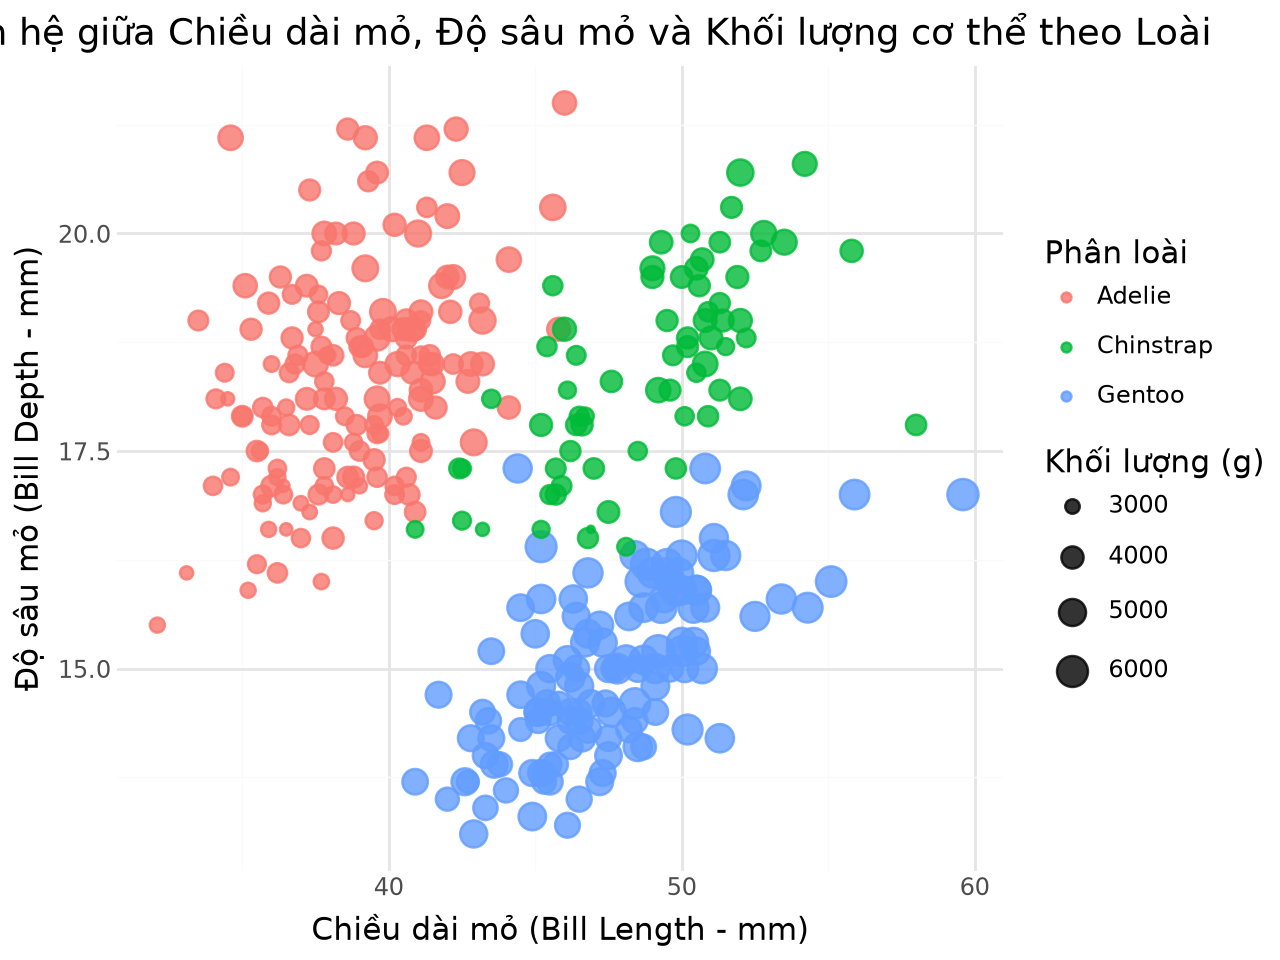

In [17]:
# TODO: Hãy viết đoạn mã plotnine trực quan hóa mối quan hệ giữa bill_length_mm và bill_depth_mm:
# - Ánh xạ "species" vào màu sắc (color)
# - Ánh xạ "body_mass_g" vào kích thước điểm (size)
# - Thêm lớp labs() để gắn nhãn tiếng Việt chuẩn mực có đơn vị đo

# YOUR CODE HERE
valid_penguins_sample = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm", "species", "body_mass_g"])
p_penguins = (
    ggplot(
        valid_penguins_sample,
        aes(x="bill_length_mm", y="bill_depth_mm", color="species", size="body_mass_g"),
    )
    + geom_point(alpha=0.8)
    + labs(
        title="Quan hệ giữa Chiều dài mỏ, Độ sâu mỏ và Khối lượng cơ thể theo Loài",
        x="Chiều dài mỏ (Bill Length - mm)",
        y="Độ sâu mỏ (Bill Depth - mm)",
        color="Phân loài",
        size="Khối lượng (g)",
    )
    + theme_minimal()
)
print(p_penguins)
p_penguins.show()

**Trả lời câu hỏi Bài 2:**

1. *Phân biệt bản chất giữa Aesthetic Mapping và Property Setting:*
> *Aesthetic Mapping (thường đặt trong hàm aes()) dùng để liên kết các đặc tính trực quan của biểu đồ (như vị trí x, y, màu sắc, kích thước) với các cột dữ liệu cụ thể trong bảng, cho phép giá trị của điểm thay đổi linh hoạt theo dữ liệu. Ngược lại, Property Setting (đặt trực tiếp trong các hàm hình học như geom_point()) dùng để thiết lập cố định một giá trị cụ thể cho toàn bộ các điểm trên biểu đồ (ví dụ: tất cả đều có kích thước bằng 2 hoặc màu xanh), không phụ thuộc vào dữ liệu.*

2. *Giải thích tại sao câu lệnh `ggplot(...) + geom_point(color="species")` bị lỗi hoặc không phân nhóm đúng:*
> *Câu lệnh này bị lỗi hoặc chạy sai vì tham số color="species" đang được gọi theo dạng Property Setting (nằm ngoài hàm aes()). Hệ thống sẽ hiểu lầm "species" là tên của một màu sắc cố định (như "red" hay "blue") thay vì một cột dữ liệu để phân nhóm.*

### BÀI 3: DÂY CHUYỀN SPLIT - APPLY - COMBINE TRÊN PALMER PENGUINS (2.0 ĐIỂM)

In [24]:
# TODO 1: Sử dụng groupby(['species', 'island']) và .agg() để tính:
# - Số lượng cá thể (count)
# - Khối lượng trung bình (mean)
# - Độ lệch chuẩn khối lượng hiệu chỉnh N-1 (std)

# YOUR CODE HERE
summary_penguins = (
    penguins.groupby(["species", "island"])["body_mass_g"]
    .agg(count="count", mean_mass="mean", std_mass=lambda x: x.std(ddof=1))
    .reset_index()
)
display(summary_penguins)

,species,island,count,mean_mass,std_mass
0,Adelie,Biscoe,44,3709.659091,487.733722
1,Adelie,Dream,56,3688.392857,455.146437
2,Adelie,Torgersen,51,3706.372549,445.107940
3,Chinstrap,Dream,68,3733.088235,384.335081
4,Gentoo,Biscoe,123,5076.016260,504.116237


In [25]:
# TODO 2: Lọc các cá thể thuộc loài Adelie hoặc Gentoo có body_mass_g > 4200 sinh sống tại đảo Biscoe
# Cách 1: dùng query()
# Cách 2: dùng boolean indexing

# YOUR CODE HERE
filtered_query = penguins.query("species in ['Gentoo', 'Adelie'] and body_mass_g > 4200 and island == 'Biscoe'")
print(f"Số cá thể thỏa mãn điều kiện: {len(filtered_query)}")
display(filtered_query.head())

Số cá thể thỏa mãn điều kiện: 124


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
51,Adelie,Biscoe,40.1,18.9,188.0,4300.0,male,2008
61,Adelie,Biscoe,41.3,21.1,195.0,4400.0,male,2008
101,Adelie,Biscoe,41.0,20.0,203.0,4725.0,male,2009
103,Adelie,Biscoe,37.8,20.0,190.0,4250.0,male,2009
109,Adelie,Biscoe,43.2,19.0,197.0,4775.0,male,2009


**Trả lời câu hỏi Bài 3:**

*Nhận xét về sự phân bố địa lý của 3 loài chim cánh cụt trên 3 hòn đảo (Biscoe, Dream, Torgersen):*
> *Sự phân bố địa lý của ba loài chim cánh cụt trên quần đảo Palmer có sự khác biệt rõ rệt và mang tính đặc trưng theo từng khu vực. Trong ba loài, Adelie là loài có phạm vi phân bố rộng nhất khi xuất hiện đồng thời trên cả ba hòn đảo (Biscoe, Dream và Torgersen). Ngược lại, hai loài còn lại chỉ sinh sống độc quyền tại một địa điểm duy nhất: loài Gentoo chỉ được tìm thấy trên đảo Biscoe, trong khi loài Chinstrap chỉ xuất hiện duy nhất trên đảo Dream.*

### BÀI 4: KHÁM PHÁ & MÔ HÌNH HÓA NGHỊCH LÝ SIMPSON (2.5 ĐIỂM)

#### Phần 1: Tỷ lệ chim cánh cụt có khối lượng > 4000g

In [26]:
# Loại bỏ các dòng có body_mass_g bị khuyết tật (NaN)
valid_penguins = penguins.dropna(subset=["body_mass_g"]).copy()
valid_penguins["is_heavy"] = valid_penguins["body_mass_g"] > 4000

# 1. Tỷ lệ gộp chung toàn quần thể
ty_le_gop = valid_penguins["is_heavy"].mean()
print(f"1. Tỷ lệ gộp chung chim cánh cụt nặng > 4000g: {ty_le_gop * 100:.2f}%")

# 2. Tỷ lệ phân rã theo từng loài
ty_le_theo_loai = valid_penguins.groupby("species")["is_heavy"].agg(
    tong_so="count",
    so_luong_heavy="sum",
    ty_le="mean"
)
ty_le_theo_loai["ty_le_pct"] = (ty_le_theo_loai["ty_le"] * 100).round(2).astype(str) + "%"
print("\n2. Tỷ lệ theo từng loài:")
display(ty_le_theo_loai)

1. Tỷ lệ gộp chung chim cánh cụt nặng > 4000g: 50.29%

2. Tỷ lệ theo từng loài:


,tong_so,so_luong_heavy,ty_le,ty_le_pct
species,,,,
Adelie,151,35,0.231788,23.18%
Chinstrap,68,15,0.220588,22.06%
Gentoo,123,122,0.991870,99.19%


#### Phần 2: Bài toán Kỹ thuật Phần mềm - Đánh giá Hiệu năng Hệ thống Server

In [27]:
# Mô phỏng dữ liệu kiểm thử 2 cụm Server A và Server B
data_servers = {
    "cluster": ["Cluster A"] * 900 + ["Cluster A"] * 100 + ["Cluster B"] * 200 + ["Cluster B"] * 800,
    "request_type": ["Lightweight"] * 900 + ["Heavyweight"] * 100 + ["Lightweight"] * 200 + ["Heavyweight"] * 800,
    "is_fast": [1] * 720 + [0] * 180 + [1] * 20 + [0] * 80 + [1] * 180 + [0] * 20 + [1] * 240 + [0] * 560
}
df_servers = pd.DataFrame(data_servers)

# 1. Tỷ lệ phản hồi nhanh gộp chung
ty_le_gop_server = df_servers.groupby("cluster")["is_fast"].mean()
print("--- Tỷ lệ phản hồi nhanh gộp chung ---")
display(ty_le_gop_server.apply(lambda x: f"{x * 100:.2f}%"))

# 2. Tỷ lệ phản hồi nhanh phân rã theo loại request
ty_le_phan_tang = df_servers.groupby(["cluster", "request_type"])["is_fast"].agg(
    tong_requests="count",
    so_fast="sum",
    ty_le_fast="mean"
)
ty_le_phan_tang["ty_le_fast_pct"] = (ty_le_phan_tang["ty_le_fast"] * 100).round(2).astype(str) + "%"
print("\n--- Tỷ lệ phản hồi nhanh phân rã theo loại Request ---")
display(ty_le_phan_tang)

--- Tỷ lệ phản hồi nhanh gộp chung ---


cluster
Cluster A    74.00%
Cluster B    42.00%
Name: is_fast, dtype: str


--- Tỷ lệ phản hồi nhanh phân rã theo loại Request ---


tong_requests  so_fast  ty_le_fast ty_le_fast_pct
cluster   request_type                                                   
Cluster A Heavyweight             100       20         0.2          20.0%
          Lightweight             900      720         0.8          80.0%
Cluster B Heavyweight             800      240         0.3          30.0%
          Lightweight             200      180         0.9          90.0%

**Trả lời câu hỏi Bài 4:**

1. *Giải thích tại sao tỷ lệ gộp chung chim cánh cụt nặng > 4000g là 50.3% lại chênh lệch mạnh với từng loài (Gentoo 99.2%, Adelie 23.2%):*
> *Hiện tượng này xảy ra do sự mất cân bằng về quy mô tập dữ liệu và đặc tính cân nặng giữa các loài chim (Nghịch lý Simpson). Loài Gentoo có kích thước cơ thể lớn vượt trội với tỷ lệ chim nặng trên 4000g đạt tới 99.19% (122/123 cá thể), trong khi loài Adelie và Chinstrap nhỏ hơn nhiều với tỷ lệ lần lượt chỉ là 23.18% và 22.06%. Khi gộp chung lại, số lượng chim nặng của Gentoo (122) chiếm áp đảo gần như toàn bộ số chim nặng của cả 3 loài (tổng 172 con), vô tình kéo tỷ lệ gộp chung lên mức trung vị ~50.3%, hoàn toàn không phản ánh đúng bức tranh phân phối cân nặng thực tế khi xét riêng từng loài.*

2. *Chỉ ra nghịch lý trong bài toán cụm máy chủ và bài học kinh nghiệm khi đánh giá hệ thống phân tán:*
> *Nghịch lý: Cụm A có tỷ lệ phản hồi nhanh gộp chung cao hơn hẳn Cụm B (74% so với 42%). Tuy nhiên, khi phân rã theo loại Request, Cụm B lại có tỷ lệ phản hồi nhanh vượt trội hơn Cụm A ở cả hai nhóm Heavyweight (30% > 20%) và Lightweight (90% > 80%). Nguyên nhân là do Cụm A nhận tới 90% yêu cầu loại nhẹ (Lightweight - dễ xử lý nhanh), còn Cụm B gánh tới 80% yêu cầu loại nặng (Heavyweight - khó xử lý nhanh).*

  *Bài học kinh nghiệm: Khi đánh giá hệ thống phân tán, không được chỉ dựa vào các chỉ số trung bình gộp chung (aggregated metrics) vì chúng dễ bị bóp méo bởi cấu trúc tải (workload mix). Bắt buộc phải phân rã dữ liệu và đánh giá theo từng nhóm đặc tính kỹ thuật tương đồng để có cái nhìn chính xác về hiệu năng thực tế của từng cụm máy chủ.*

### BÀI 5: TƯ DUY PHẢN BIỆN & THIẾT KẾ DỮ LIỆU CÓ TRÁCH NHIỆM (1.0 ĐIỂM)

1. *Phản biện nhận định của Giám đốc sản phẩm về A/B Testing:*
> *Nhận định cho rằng phiên bản mới chiến thắng dựa trên tỷ lệ chuyển đổi gộp chung (aggregated conversion rate) cao hơn là chưa đủ cơ sở vững chắc và có nguy cơ sai lầm do bẫy Nghịch lý Simpson. Khi lượng traffic phân bổ vào các nhóm người dùng (ví dụ: người dùng cũ vs người dùng mới, hoặc các quốc gia/thiết bị khác nhau) bị mất cân bằng lớn, tỷ lệ gộp chung sẽ bị bóp méo bởi nhóm chiếm đa số. Phiên bản mới có thể thắng ở tổng thể nhưng thực tế lại có hiệu năng tệ hơn phiên bản cũ trên từng phân khúc khách hàng cụ thể, dẫn đến quyết định triển khai sai lầm.*

2. *Hai nguyên tắc thực hành (Best Practices) giúp đội ngũ kỹ thuật tránh bẫy Nghịch lý Simpson:*
> *Nguyên tắc 1: Phân tầng dữ liệu và đánh giá đa chiều (Stratified Analysis): Không bao giờ kết luận dựa duy nhất vào một chỉ số trung bình gộp chung. Đội ngũ kỹ thuật cần xác định trước các biến gây nhiễu chính (confounding variables) để phân rã dữ liệu và so sánh hiệu năng chi tiết theo từng phân khúc người dùng tương đồng.*
*Nguyên tắc 2: Phân bổ dữ liệu đồng đều khi thiết kế thử nghiệm (Balanced Allocation): Khi thiết kế A/B Testing hoặc thu thập dữ liệu, cần kiểm soát quy mô mẫu và tỷ lệ phân luồng traffic sao cho đồng đều giữa các nhóm đối tượng (ví dụ: áp dụng kỹ thuật Stratified Sampling). Việc giữ tỷ lệ phân bổ tải ổn định và nhất quán sẽ triệt tiêu tác động bóp méo chỉ số của các nhóm dữ liệu áp đảo.*